# Analiza danych oraz wyników predykcji

## I. Analiza zbioru danych

#### Wczytanie oraz wstępne czyszczenie danych

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
df['loan_status'] = df['loan_status'].str.strip()
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df.drop(columns=['loan_id'], inplace=True)

#### Mapowanie

W naszym zbiorze danych znajdują się 3 kolumny przechowujące wartości tekstowe (tzw. zmienne kategoryczne): education, self_employed oraz zmienna docelowa loan_status. Ponieważ algorytmy uczenia maszynowego do wykonywania obliczeń matematycznych wymagają na wejściu wyłącznie danych liczbowych, zamieniamy te wartości na dane binarne (0 i 1). Krok ten jest niezbędny do przeprowadzenia prawidłowej analizy eksploracyjnej (EDA) oraz poprawnego wytrenowania modelu.

In [3]:
status_map = {"Approved": 1, "Rejected": 0}
edu_map = {"Graduate": 1, "Not Graduate": 0}
emp_map = {"Yes": 1, "No": 0}

df['loan_status'] = df['loan_status'].replace(status_map)
df['education'] = df['education'].replace(edu_map)
df['self_employed'] = df['self_employed'].replace(emp_map)

df['education'] = df['education'].astype(int)
df['self_employed'] = df['self_employed'].astype(int)
df['loan_status'] = df['loan_status'].astype(int)

#### Przeliczenie walut
Walutą użytą w tym zbiorze jest Rupia Indyjska. Dla czytelności poniższej analizy eksploracyjnej przeliczymy wybrane kolumny finansowe na dolary amerykańskie (USD)

In [4]:
financial_columns = [
    'income_annum',
    'loan_amount',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

# Przybliżony kurs wymiany: 1 USD = 83 INR
exchange_rate = 83

for col in financial_columns:
    df[col] = round(df[col] / exchange_rate, 2)

#### Opis zmiennych

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   education                 4269 non-null   int64  
 2   self_employed             4269 non-null   int64  
 3   income_annum              4269 non-null   float64
 4   loan_amount               4269 non-null   float64
 5   loan_term                 4269 non-null   int64  
 6   cibil_score               4269 non-null   int64  
 7   residential_assets_value  4269 non-null   float64
 8   commercial_assets_value   4269 non-null   float64
 9   luxury_assets_value       4269 non-null   float64
 10  bank_asset_value          4269 non-null   float64
 11  loan_status               4269 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 400.3 KB


- <b>education</b> – Poziom wykształcenia klienta. W pierwotnym pliku były to wartości tekstowe ("Graduate" / "Not Graduate"), które zmapowaliśmy na wartości binarne
- <b>self_employed</b> – Informacja o tym, czy klient prowadzi własną działalność gospodarczą / jest samozatrudniony (oryginalnie "Yes" / "No")
- <b>income_annum</b> – Roczny dochód klienta wyrażony w walucie
- <b>loan_amount</b> – Całkowita wnioskowana kwota kredytu
- <b>loan_term</b> – Okres kredytowania. Wartości w zbiorze (np. 2, 10, 20) wskazują, że jest to czas spłaty zobowiązania wyrażony w latach
- <b>cibil_score</b> – Skoring kredytowy (odpowiednik polskiego BIK). Jest to ocena historii kredytowej klienta – im wyższa liczba, tym klient jest bardziej wiarygodny dla banku
- <b>residential_assets_value</b> – Rynkowa wycena majątku mieszkaniowego (nieruchomości mieszkalnych) należącego do klienta
- <b>commercial_assets_value</b> – Wartość majątku komercyjnego (np. lokali użytkowych, biur)
- <b>luxury_assets_value</b> – Szacowana wartość dóbr luksusowych posiadanych przez osobę wnioskującą o kredyt
- <b>bank_asset_value</b> – Wartość płynnych aktywów finansowych i oszczędności zgromadzonych na kontach bankowych
- <b>loan_status</b> – Nasza zmienna docelowa (tzw. target variable). Określa ostateczną decyzję banku ("Approved" - przyznany / "Rejected" - odrzucony), której nasz model uczy się przewidywać

#### Statystyki opisowe

In [6]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000
mean,2.498712,0.502225,0.503631,60953.300171,182330.728402,10.900445,599.936051,90031.524565,59917.533785,182244.649695,59960.149862,0.622160
std,1.695910,0.500054,0.500045,33817.347277,108956.180569,5.709187,172.430401,78357.067316,52879.109405,109683.779016,39158.859025,0.484904
min,0.000000,0.000000,0.000000,2409.640000,3614.460000,2.000000,300.000000,-1204.820000,0.000000,3614.460000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,32530.120000,92771.080000,6.000000,453.000000,26506.020000,15662.650000,90361.450000,27710.840000,0.000000
50%,3.000000,1.000000,1.000000,61445.780000,174698.800000,10.000000,600.000000,67469.880000,44578.310000,175903.610000,55421.690000,1.000000
75%,4.000000,1.000000,1.000000,90361.450000,259036.140000,16.000000,748.000000,136144.580000,91566.270000,261445.780000,85542.170000,1.000000
max,5.000000,1.000000,1.000000,119277.110000,475903.610000,20.000000,900.000000,350602.410000,233734.940000,472289.160000,177108.430000,1.000000


Średnia dla kolumn education oraz self_employed wynosi ok. 0.50, co oznacza, że dane są niemal idealnie podzielone w proporcji 50/50 pomiędzy osoby z wyższym wykształceniem oraz bez niego, a także pomiędzy samozatrudnionych i pracujących u kogoś.

Średnia dla decyzji kredytowych wynosi około 0.62, co jasno wskazuje, że nasz model będzie uczył się na zbiorze, w którym bank zaakceptował 62,2% wniosków o kredyt, a odrzucił 37,8% z nich.

Średni roczny dochód to niespełna 61 tysięcy dolarów, natomiast średnia wnioskowana kwota kredytu (loan_amount) wynosi ponad 182 tysiące dolarów. Oznacza to, że klienci średnio wnioskują o kwotę 3-krotnie przewyższającą ich roczne zarobki. Najwyższy wnioskowany kredyt opiewa na niemal 476 tys. dolarów.

Klienci chcą spłacać swoje zobowiązania przez okres od 2 do 20 lat, a średni czas to prawie 11 lat.

Punktacja historii kredytowej waha się w równym przedziale od 300 do 900, ze średnią wynoszącą dokładnie 600 punktów.

W kolumnie oceniającej majątek mieszkaniowy wartość minimalna (min) jest ujemna i wynosi -1204.82. Może to oznaczać zadłużenie przewyższające wartość nieruchomości lub literówkę w danych wprowadzonych do systemu. Aby dowiedzieć się więcej, sprawdzimy, czy nasz zbiór posiada więcej ujemnych wartości.

In [7]:
ujemne_wartosci = df[df['residential_assets_value'] < 0]
ujemne_wartosci['residential_assets_value'].value_counts()

residential_assets_value
-1204.82    28
Name: count, dtype: int64

Widzimy, że takich wartości w naszym zbiorze jest dokładnie 28 i wynoszą one dokładnie tyle samo w każdym przypadku. Skoro wszystkie wartości ujemne są sobie równe, prawdopodobnie nie oznaczają one zadłużenia, a raczej są błędem bądź placeholderem, dlatego usuniemy je ze zbioru danych.

In [8]:
df = df[df['residential_assets_value'] >= 0]

#### Badanie korelacji

In [9]:
df.corr()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
no_of_dependents,1.000000,0.003550,0.003555,0.008782,-0.002474,-0.020839,-0.006890,0.007930,0.000213,0.004003,0.012301,-0.015696
education,0.003550,1.000000,-0.022422,0.012664,0.011774,-0.008829,-0.006495,0.012641,-0.006407,0.013428,0.010625,0.004819
self_employed,0.003555,-0.022422,1.000000,0.002317,0.001243,0.004785,-0.008821,0.006689,-0.019196,0.003971,-0.000193,-0.001971
income_annum,0.008782,0.012664,0.002317,1.000000,0.927083,0.011594,-0.023502,0.636327,0.638891,0.928698,0.850242,-0.018035
loan_amount,-0.002474,0.011774,0.001243,0.927083,1.000000,0.008246,-0.017469,0.593993,0.601610,0.859928,0.787081,0.013678
loan_term,-0.020839,-0.008829,0.004785,0.011594,0.008246,1.000000,0.008478,0.007729,-0.004294,0.012534,0.017549,-0.114665
cibil_score,-0.006890,-0.006495,-0.008821,-0.023502,-0.017469,0.008478,1.000000,-0.018415,-0.005303,-0.029366,-0.015406,0.771286
residential_assets_value,0.007930,0.012641,0.006689,0.636327,0.593993,0.007729,-0.018415,1.000000,0.414589,0.590349,0.526310,-0.015292
commercial_assets_value,0.000213,-0.006407,-0.019196,0.638891,0.601610,-0.004294,-0.005303,0.414589,1.000000,0.589326,0.546808,0.005625
luxury_assets_value,0.004003,0.013428,0.003971,0.928698,0.859928,0.012534,-0.029366,0.590349,0.589326,1.000000,0.787581,-0.018346


Na podstawie macierzy korelacji możemy wyciągnąć kilka kluczowych wniosków:
Wskaźnik historii kredytowej wykazuje najsilniejszą, dodatnią korelację ze zmienną docelową loan_status na poziomie 0.77. Oznacza to, że zmienna cibil_score jest głównym determinantem, jeżeli chodzi o przyznanie kredytu.

Roczne zarobki są silnie powiązane z wnioskowaną kwotą kredytu (0.92), wartością majątku luksusowego (0.93) oraz oszczędnościami bankowymi (0.85). Co ciekawe, te zmienne majątkowe same w sobie wykazują niemal zerową korelację liniową z decyzją o przyznaniu kredytu.

Cechy takie jak wykształcenie, samozatrudnienie czy liczba osób na utrzymaniu wykazują korelacje bliskie zeru (np. od -0.02 do 0.01) w stosunku do pozostałych parametrów, w tym samej decyzji kredytowej.

Zjawisko silnej współliniowości cech majątkowych (rzędu 0.90+) w klasycznych algorytmach (np. regresja logistyczna) wymagałoby usunięcia części zmiennych. Ponieważ jednak decydujemy się na zastosowanie algorytmu Lasu Losowego (Random Forest), który w naturalny sposób radzi sobie ze współliniowością, możemy bezpiecznie zachować wszystkie kolumny w zbiorze. Na podstawie macierzy przewidujemy, że cibil_score zdominuje ostateczny wykres ważności cech (Feature Importance).

## II. Przygotowanie danych do modelu
Zmienną objaśnianą będzie decyzja odnośnie przyznania kredytu. Tworzymy zmienne X oraz y, gdzie X to wszystkie kolumny poza loan_status, która trafia do wektora y. Dane dzielimy na zestaw treningowy oraz testowy według proporcji 80% do 20%. Ustawiamy również ziarno, aby wyniki pozostawały takie same przy każdym odpaleniu raportu.

In [10]:
X = df.drop(columns = ['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## III. Budowa modelu i analiza predykcji
Do przewidzenia decyzji kredytowej wykorzystamy algorytm klasyfikacji – Las Losowy (Random Forest Classifier). Po wytrenowaniu algorytmu na zbiorze treningowym dokonamy predykcji na zbiorze testowym. Skuteczność naszego modelu ocenimy za pomocą:
- Dokładności (Accuracy) – ogólnego odsetka poprawnych trafień,
- Raportu Klasyfikacji (Classification Report) – pokazującego precyzję (precision) i czułość (recall) dla każdej z klas,
- Macierzy Błędu (Confusion Matrix) – wizualizacji, która precyzyjnie wskaże, w których miejscach model podjął błędną decyzję.

#### Raport klasyfikacji

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność modelu (Accuracy): {accuracy * 100:.2f}%\n")

print(classification_report(y_test, y_pred))

Dokładność modelu (Accuracy): 98.47%

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       306
           1       0.99      0.98      0.99       543

    accuracy                           0.98       849
   macro avg       0.98      0.99      0.98       849
weighted avg       0.98      0.98      0.98       849



Precyzja mówi o tym, jak bardzo możemy ufać modelowi, gdy ten twierdzi, że rozpoznał daną klasę.
Na podstawie wyników widzimy, że gdy model przewiduje przyznanie kredytu (klasa 1), ma rację w 99% przypadków, natomiast gdy przewiduje odrzucenie (klasa 0), ma rację w 97% przypadków.

Czułość (Recall): Mówi o tym, jak dobrze model wyłapuje wszystkie rzeczywiste przypadki danej klasy z całego zbioru.
Dla odrzuceń (klasa 0) wynosi 0.99. Oznacza to, że model zdołał poprawnie znaleźć 99% wszystkich przypadków odrzucenia kredytu.
Dla przyznań (klasa 1) wynosi 0.98. Model zdołał poprawnie znaleźć 98% wszystkich faktycznych przypadków przyznania kredytu.

F1-score: To uśredniona miara łącząca precyzję i czułość w jeden wskaźnik.
Wyniki na poziomie 0.98 dla przyznań i 0.99 dla odrzuceń oznaczają, że model jest świetnie zbalansowany i wysoce wiarygodny dla obu analizowanych klas.

#### Confusion Matrix

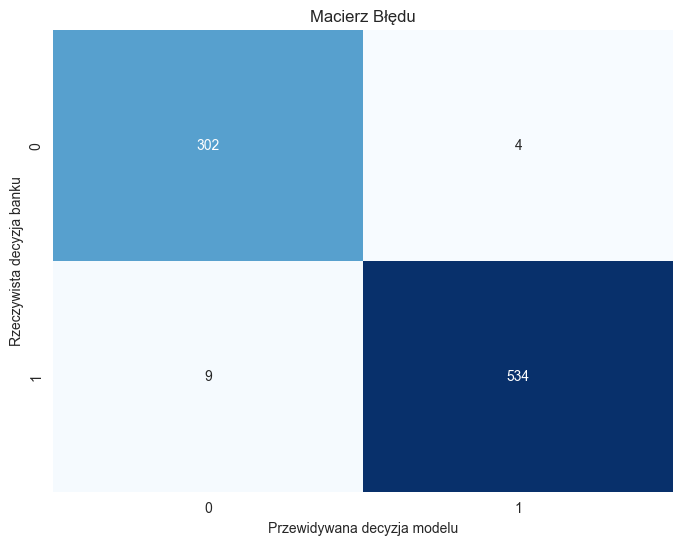

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Macierz Błędu')
plt.xlabel('Przewidywana decyzja modelu')
plt.ylabel('Rzeczywista decyzja banku')
plt.show()

Prawdziwie Negatywne (True Negatives): Model poprawnie przewidział odrzucenie kredytu 302 razy.

Prawdziwie Pozytywne (True Positives): Model poprawnie przewidział decyzję przyznania kredytu 534 razy.

Fałszywie Pozytywne (False Positives): Sytuacje, kiedy model przewidział przyznanie kredytu, jednak w rzeczywistości bank go nie udzielił – 4 przypadki.

Fałszywie Negatywne (False Negatives): Sytuacje, kiedy model przewidział odrzucenie wniosku, a w rzeczywistości bank udzielił kredytu – 9 przypadków.

#### Ważność cech

Ostatnim krokiem analizy jest weryfikacja, którymi kryteriami model Losowego Lasu kierował się najbardziej przy podejmowaniu decyzji o przyznaniu kredytu. Weryfikuje to nasze wcześniejsze założenia z Eksploracyjnej Analizy Danych (EDA), gdzie na podstawie macierzy korelacji wywnioskowaliśmy, że historia kredytowa będzie miała największy wpływ na ostateczny wynik.

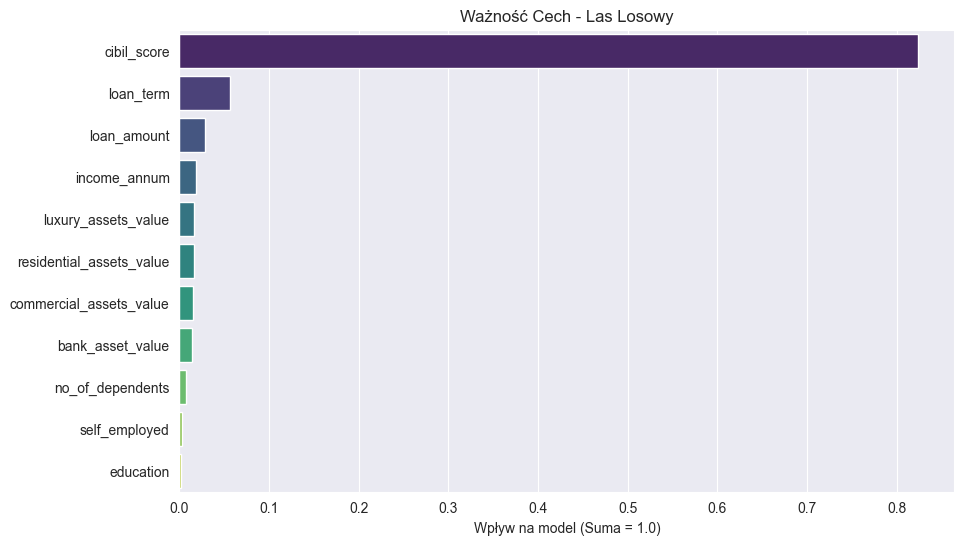

In [13]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Cecha': X_train.columns,
    'Ważność': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Ważność', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Ważność',
    y='Cecha',
    data=feature_importance_df,
    hue='Cecha',
    palette='viridis',
    legend=False
)
plt.title('Ważność Cech - Las Losowy')
plt.xlabel('Wpływ na model (Suma = 1.0)')
plt.ylabel('')
plt.show()

Powyższy wykres ostatecznie potwierdza nasze wcześniejsze przypuszczenia wyciągnięte z analizy korelacji – zdecydowanie największy wpływ na decyzję banku ma ocena historii kredytowej klienta (cibil_score), która odpowiada za około 80% procesu decyzyjnego algorytmu. Z drugim wynikiem plasuje się termin spłaty kredytu (loan_term), którego waga wynosi około 10%. Najniższy wpływ spośród wszystkich badanych parametrów mają zmienne demograficzne, takie jak wykształcenie (education) oraz samozatrudnienie (self_employed).